#What is the gradient descent?


From the view of mathmatics, gradient descent is find the point of convergence from a randoom point in target function. The specific process is we will move the start point few times so it finally overlap the covergence point. In order to do that, we should focus on two parameters---derivative and leaning rate. 

The derivative tells us the direction of convergence point, since it describe the tendency of function's change. In addition, the learning rate is the step of how to approach the convergence point. If the learning rate is too large, the movement may lead the point ignore the target point. Conversely, a over tiny learning rate will cost lots of steps to do that, which means more time and resource. So a suitable learning rate is important. 

The following code will show a animation about how the gradient descent work in a sample function graph.

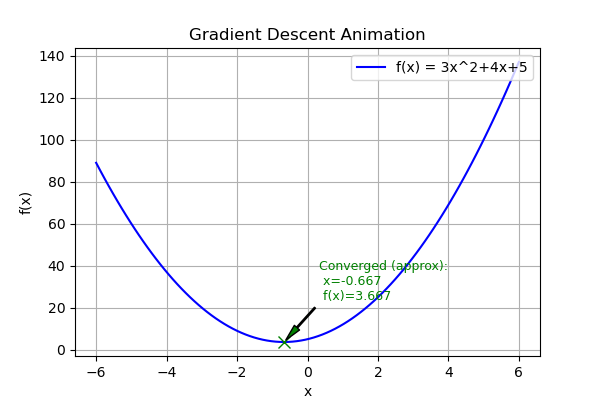

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
%matplotlib widget


# Function and derivative
def f(x): 
    return 3*x**2 + 4*x + 5

def df(x): 
    return 6*x + 4

# Gradient descent parameters
x_start = 5  # Starting point
learning_rate = 0.1
iterations = 20
steps = []
x = x_start # Initialize x for the loop

# Simulate gradient descent
for i in range(iterations):
    steps.append(x) # Store current x before updating
    gradient = df(x)
    x = x - learning_rate * gradient
# Add the final position after the last update
steps.append(x)

# --- Explicitly create Figure and Axes with a specific size ---
fig2, ax2 = plt.subplots(figsize=(6, 4)) # Adjusted size slightly for text

# --- Plot setup using the axes object 'ax2' ---
x_plot_vals = np.linspace(-6, 6, 100) 
ax2.plot(x_plot_vals, f(x_plot_vals), label='f(x) = 3x^2+4x+5', color='blue')
point, = ax2.plot([], [], 'ro', label='Current Position')  # Red dot for current position

# Add text object for coordinates (position relative to axes: 0.05 from left, 0.9 from bottom)
coord_text = ax2.text(0.05, 0.9, '', transform=ax2.transAxes, fontsize=9)

# Set axis labels and title
ax2.set_xlabel('x')
ax2.set_ylabel('f(x)')
ax2.set_title('Gradient Descent Animation')
ax2.grid(True)
# Create legend (only for the function line initially)
ax2.legend(handles=[ax2.get_lines()[0]], loc='upper right') # Only label the function line

# Animation function
def update(frame):
    current_x = steps[frame]
    current_y = f(current_x)
    point.set_data([current_x], [current_y])
    # Update coordinate text for the current frame
    coord_text.set_text(f'Step {frame}: x={current_x:.3f}, f(x)={current_y:.3f}') 
    # Return all artists that need updating for blitting
    return point, coord_text

# Calculate the final convergence point coordinates
final_x = steps[-1]
final_y = f(final_x)

# Add an annotation for the final point (static)
ax2.annotate(f'Converged (approx):\n x={final_x:.3f}\n f(x)={final_y:.3f}',
             xy=(final_x, final_y), 
             xytext=(final_x + 1, final_y + 20), # Adjust text position offset
             arrowprops=dict(facecolor='green', shrink=0.05, width=1, headwidth=5),
             fontsize=9,
             color='green')
# Optionally, add a marker for the final point
ax2.plot(final_x, final_y, 'gx', markersize=8) # Green 'x' marker

# Pass the specific figure 'fig2' to FuncAnimation
# Set interval to 1000 ms (1 second)
ani = FuncAnimation(fig2, update, frames=range(len(steps)), interval=1000, blit=True, repeat=False)

plt.show()

#Gradient descent and neural network

In neural network, after an iteration, the outcome may deviate the real situation(if they match too closely, then overfitting should be concerned), and the error will apppear. Here, we want to neural network to do some adjustments, so it can learn from this epoch, and do better in next time. We quote loss function to describe these errors. Let's go through MSE as an example.

A simple linear neural: y_p = w*x + b; y_p:the predicted value x: input value w,b:paraneters

The MSE of this neural:L = 1/n * ∑ (y_t - (w*x + b))^2; y_t:the true value 

We want to update parameters, so lets find the gradient of w and b:

dL/dw = 1/n * ∑ 2*(y_t - (w*x + b)) * (-x) = -2/n ∑ x*(y_t - y_p)

dL/db = 1/n * ∑ 2*(y_t - (w*x + b)) * (-1) = -2/n ∑ (y_t - y_p)
​
After that, we can set learning rate (η) and do update:

w_new = w - η * (-2/n ∑ x*(y_t - y_p))

b_new = b - η * (-2/n ∑ x*(y_t - y_p))

The next iteration will use w_new and b_new as parameters.